# Phase 2 — Feature Engineering
### Project: Predicting Protein Thermostability from Sequence Features
**Author:** Mauli Bhavsar  
**Date:** April 2026  

---

## What is Feature Engineering?

In Phase 1, we prepared a clean dataset of 35,999 labelled proteins. 
Each protein is currently represented as a raw amino acid sequence — 
a string of letters like `MKKQTLSEWIEQLR...`

Machine learning models **cannot learn from raw text**. They only 
understand numbers. Feature engineering is the process of converting 
raw data into **meaningful numerical representations** that a model 
can learn from.

The word **feature** simply means a measurable property of your data.
For example:
- If predicting house prices → features might be: size, rooms, location
- For us → features are physicochemical properties of the protein sequence

The critical word is **meaningful**. We are not randomly converting 
letters to numbers. Every feature we compute has a **biological reason** 
for why it might help distinguish thermostable from mesostable proteins. 
This is where bioinformatics knowledge matters more than any ML trick.

---

## The Tool — Biopython ProtParam

All features are computed using **Biopython's ProtParam module**. 
ProtParam takes a protein sequence and computes physicochemical 
properties from it. It is the Python equivalent of the ExPASy ProtParam 
web tool that biologists use manually — we are just automating it for 
35,999 proteins at once.

---

## The 26 Features We Compute

### Group 1 — Amino Acid Composition (20 features)

For each of the 20 standard amino acids, we compute what **fraction** 
of the sequence is made up of that amino acid.

Example: if a protein is 300 amino acids long and 24 are Alanine:
AA_A = 24 / 300 = 0.08

Different amino acids contribute very differently to thermal stability:

| Amino Acid | Code | Role in thermostability |
|------------|------|------------------------|
| Arginine | R | Forms strong salt bridges — enriched in thermostable proteins |
| Isoleucine | I | Aliphatic — packs tightly in core — enriched in thermostable proteins |
| Leucine | L | Aliphatic — same as above |
| Valine | V | Aliphatic — same as above |
| Alanine | A | Aliphatic — same as above |
| Asparagine | N | Deamidates at high temperatures — depleted in thermostable proteins |
| Glutamine | Q | Deamidates at high temperatures — depleted in thermostable proteins |
| Glycine | G | Makes chains flexible — depleted in thermostable proteins |
| Cysteine | C | Can oxidise at high temperatures — depleted in thermostable proteins |

### Group 2 — Global Physicochemical Properties (6 features)

| Feature | What it measures | Why it matters |
|---------|-----------------|----------------|
| **Molecular weight** | Total mass in Daltons | Larger proteins have more stabilising interactions |
| **Isoelectric point (pI)** | pH at which protein has zero net charge | Affects salt bridge formation at high temperatures |
| **GRAVY score** | Overall hydrophobicity of the sequence | Thermostable proteins tend to have tighter hydrophobic cores |
| **Instability index** | Predicted chemical instability | Values > 40 suggest unstable protein |
| **Aromaticity** | Fraction of Phe (F), Trp (W), Tyr (Y) | Aromatic rings form pi-stacking interactions that stabilise cores |
| **Aliphatic index** | Relative content of Ala, Val, Ile, Leu | One of the strongest known predictors of thermostability |

### The Aliphatic Index Formula

The aliphatic index is computed manually using the Ikai (1980) formula:
Aliphatic Index = AA_A + 2.9 × AA_V + 3.9 × (AA_I + AA_L)

The multipliers (2.9 and 3.9) reflect how much each amino acid 
contributes to the aliphatic side chain volume. This index has been 
validated many times as a strong positive correlate of thermostability.

---

## What Will Our Feature Matrix Look Like?

After this phase, our dataset goes from 4 columns to 29 columns:
protein_id | AA_A | AA_C | ... (20 AA columns) ... | mol_weight | pI | gravy | instability | aromaticity | aliphatic | tm | label

That is **26 features** per protein across 35,999 proteins — a 
**35,999 × 26 feature matrix**. This is what gets fed into our 
ML models in Phase 4.

## Step 1 — Imports and File Paths

In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────

# pandas: for loading and manipulating our data table
import pandas as pd

# numpy: for numerical operations
import numpy as np

# ProteinAnalysis: the core Biopython class that computes all
# physicochemical properties from a protein sequence
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# tqdm: shows a progress bar when looping over many items
# Without this we would have no idea how long the computation will take
from tqdm import tqdm

# os: for file path operations
import os

# matplotlib and seaborn: for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print("All imports successful!")

All imports successful!


## Step 2 — Load the Clean Dataset

We load the clean labelled dataset we prepared in Phase 1.
This file has 4 columns: protein_id, sequence, tm, label.

In [4]:
# Load the clean dataset from Phase 1
df = pd.read_csv('../data/processed/02_dataset_clean.csv')

print(f"Dataset loaded successfully!")
print(f"Shape : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 2 rows (sequence truncated):")
df_display = df.head(2).copy()
df_display['sequence'] = df_display['sequence'].str[:30] + '...'
print(df_display.to_string(index=False))

Dataset loaded successfully!
Shape : (36100, 4)
Columns: ['protein_id', 'sequence', 'tm', 'label']

First 2 rows (sequence truncated):
                                            protein_id                          sequence        tm  label
A0A0K2H409_Geobacillus_stearothermophilus_NCA26_lysate MKKQTLSEWIEQLRQDPNVVYWHEIEPKEA... 70.937807      1
A0A0K2H416_Geobacillus_stearothermophilus_NCA26_lysate MKLYDSILDLIGGTPIVKLRRLPDPNGAEV... 72.330714      1


## Step 3 — Understanding ProtParam

Before computing features for all 35,999 proteins, let's first 
understand exactly what ProtParam does by testing it on a single 
protein sequence.

This is always good practice — test your function on one example 
before running it on the entire dataset.

### How ProtParam Works

```python
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Step 1: Create an analysis object from a sequence string
analysis = ProteinAnalysis("MKKQTLSEW...")

# Step 2: Call methods/properties to get each feature
analysis.molecular_weight()    # total mass in Daltons
analysis.isoelectric_point()   # pH at zero net charge
analysis.gravy()               # hydrophobicity score
analysis.instability_index()   # stability prediction
analysis.aromaticity()         # fraction of aromatic AAs
analysis.amino_acids_percent   # dictionary of AA fractions
```

Note: `amino_acids_percent` has no parentheses — it is a 
**property** not a method in Biopython 1.87.

In [5]:
# Test ProtParam on the first protein in our dataset
test_sequence = df['sequence'].iloc[0]
test_id       = df['protein_id'].iloc[0]

print(f"Testing on: {test_id[:50]}...")
print(f"Sequence  : {test_sequence[:40]}...")
print(f"Length    : {len(test_sequence)} amino acids")
print()

# Create the ProteinAnalysis object
analysis = ProteinAnalysis(test_sequence)

# Compute each feature individually and print
print("=== Computed Features ===")
print(f"Molecular weight : {analysis.molecular_weight():.2f} Daltons")
print(f"Isoelectric point: {analysis.isoelectric_point():.2f}")
print(f"GRAVY score      : {analysis.gravy():.4f}")
print(f"Instability index: {analysis.instability_index():.2f}")
print(f"Aromaticity      : {analysis.aromaticity():.4f}")

# Amino acid composition — returns a dictionary of 20 values
aa_comp = analysis.amino_acids_percent
print(f"\nAmino acid composition (first 5):")
for aa, pct in list(aa_comp.items())[:5]:
    print(f"  AA_{aa}: {pct:.4f} ({pct*100:.2f}%)")

# Compute aliphatic index manually
aliphatic = (aa_comp['A'] + 
             2.9 * aa_comp['V'] + 
             3.9 * (aa_comp['I'] + aa_comp['L']))
print(f"\nAliphatic index  : {aliphatic:.4f}")
print(f"\nThis protein has label: {df['label'].iloc[0]} (1=thermostable, 0=mesostable)")

Testing on: A0A0K2H409_Geobacillus_stearothermophilus_NCA26_ly...
Sequence  : MKKQTLSEWIEQLRQDPNVVYWHEIEPKEANFVPFPDELD...
Length    : 758 amino acids

=== Computed Features ===
Molecular weight : 84824.00 Daltons
Isoelectric point: 6.25
GRAVY score      : -0.1328
Instability index: 45.28
Aromaticity      : 0.0831

Amino acid composition (first 5):
  AA_A: 9.7625 (976.25%)
  AA_C: 1.3193 (131.93%)
  AA_D: 4.7493 (474.93%)
  AA_E: 7.2559 (725.59%)
  AA_F: 3.4301 (343.01%)

Aliphatic index  : 96.2533

This protein has label: 1 (1=thermostable, 0=mesostable)


### Interpretation

Look at the values we just computed for this thermostable protein 
(label=1):

- **Aliphatic index** — if this is high (typically > 0.5 for 
  thermostable proteins), it confirms the protein has a high content 
  of aliphatic amino acids — a known thermostability signal
- **Instability index** — values below 40 suggest a stable protein, 
  consistent with thermostability
- **GRAVY score** — a positive value would suggest hydrophobic 
  character, consistent with a tightly packed thermostable core

These single-protein results already give us biological intuition 
before we compute features for all 35,999 proteins.

## Step 4 — The Feature Engineering Function

Now we define the function that computes all 26 features for any 
protein sequence. We will then apply this function to all 35,999 
proteins in our dataset.

A **function** in Python is a reusable block of code. Instead of 
writing the same feature computation 35,999 times, we write it once 
as a function and call it in a loop.

```python
def function_name(input):
    # do something
    return output
```

In [6]:
def compute_features(sequence):
    """
    Takes a single protein sequence as a string (e.g. "MKKQTLSEW...")
    and returns a dictionary of 26 physicochemical features.
    
    A dictionary in Python stores key-value pairs:
    {'feature_name': value, 'feature_name2': value2, ...}
    
    We use a dictionary so each feature has a clear name that will
    become a column name in our final table.
    """
    
    # Create a ProteinAnalysis object from the sequence string
    # This is the main Biopython object that computes all properties
    analysis = ProteinAnalysis(sequence)
    
    # ── Feature Group 1: Amino Acid Composition (20 features) ─────────────────
    # amino_acids_percent is a property (no parentheses) that returns
    # a dictionary like: {'A': 0.082, 'C': 0.014, 'D': 0.054, ...}
    # for all 20 standard amino acids
    aa_comp = analysis.amino_acids_percent
    
    # ── Feature Group 2: Global Physicochemical Properties (6 features) ───────
    
    # molecular_weight(): total mass of the protein in Daltons
    # computed by summing the masses of all amino acids
    mol_weight = analysis.molecular_weight()
    
    # isoelectric_point(): pH at which protein carries zero net charge
    # computed by finding the pH where positive and negative charges balance
    isoelectric = analysis.isoelectric_point()
    
    # gravy(): Grand Average of Hydropathy
    # computed by averaging Kyte-Doolittle hydrophobicity values for each AA
    # Positive = overall hydrophobic, Negative = overall hydrophilic
    gravy = analysis.gravy()
    
    # instability_index(): predicts chemical stability of the protein
    # Based on dipeptide composition — values > 40 suggest unstable protein
    instability = analysis.instability_index()
    
    # aromaticity(): fraction of aromatic amino acids (Phe, Trp, Tyr)
    # computed as (count of F + W + Y) / total sequence length
    aromaticity = analysis.aromaticity()
    
    # Aliphatic index: computed manually using Ikai (1980) formula
    # Measures relative volume occupied by aliphatic side chains (A, V, I, L)
    # Multipliers reflect the volume contribution of each amino acid's side chain
    aliphatic = (aa_comp['A'] + 
                 2.9 * aa_comp['V'] + 
                 3.9 * (aa_comp['I'] + aa_comp['L']))
    
    # ── Build the final feature dictionary ────────────────────────────────────
    # Start with an empty dictionary and fill it with our features
    features = {}
    
    # Add all 20 amino acid composition values
    # f'AA_{aa}' creates names like 'AA_A', 'AA_C', 'AA_D', etc.
    for aa, percent in aa_comp.items():
        features[f'AA_{aa}'] = percent
    
    # Add the 6 global physicochemical properties
    features['mol_weight']   = mol_weight
    features['isoelectric']  = isoelectric
    features['gravy']        = gravy
    features['instability']  = instability
    features['aromaticity']  = aromaticity
    features['aliphatic']    = aliphatic
    
    # Return the completed dictionary of 26 features
    return features

print("compute_features() function defined successfully!")
print("Ready to apply to all 35,999 proteins.")

compute_features() function defined successfully!
Ready to apply to all 35,999 proteins.


## Step 5 — Compute Features for All Proteins

Now we apply `compute_features()` to every protein in our dataset 
using a loop. We wrap the loop with `tqdm()` to get a progress bar.

### What is a try/except block?

```python
try:
    # attempt to do something
except Exception as e:
    # if it fails, do this instead
```

We use this because some protein sequences may contain unusual 
characters that ProtParam cannot handle. Instead of crashing the 
entire script, we catch those errors gracefully and move on.

In [7]:
print("Computing features for all proteins...")
print("(Watch the progress bar!)\n")

# We collect one feature dictionary per protein in this list
all_features = []

# tqdm() wraps the loop and shows a live progress bar
# desc= sets the label shown next to the progress bar
for sequence in tqdm(df['sequence'], desc="Computing features"):
    try:
        # Compute all 26 features for this sequence
        features = compute_features(sequence)
        all_features.append(features)
    except Exception as e:
        # If this sequence caused an error, append None
        # We will remove these None entries after the loop
        all_features.append(None)

print(f"\nLoop complete!")
print(f"Total results collected: {len(all_features):,}")
print(f"Failed (None): {sum(1 for f in all_features if f is None)}")
print(f"Successful   : {sum(1 for f in all_features if f is not None):,}")

Computing features for all proteins...
(Watch the progress bar!)



Computing features: 100%|██████████| 36100/36100 [00:06<00:00, 5338.21it/s]


Loop complete!
Total results collected: 36,100
Failed (None): 101
Successful   : 35,999


## Step 6 — Build the Feature Matrix

Now we convert our list of dictionaries into a pandas DataFrame — 
the feature matrix. We also remove any failed proteins and add back 
the protein_id, tm and label columns.

### Why do we add protein_id, tm and label back?

When we built `all_features`, we only stored the 26 computed feature 
values — not the protein ID, Tm or label. This is because these are 
not features (they are identifiers and targets), so we kept them 
separate and now add them back to the final table.

In [8]:
print("Building feature matrix...")

# Find indices of proteins that failed (where we stored None)
failed_indices = [i for i, f in enumerate(all_features) if f is None]
print(f"  Proteins that failed: {len(failed_indices)}")
print(f"  Reason: unusual amino acid characters ProtParam cannot handle")

# Remove None values from the features list
all_features_clean = [f for f in all_features if f is not None]

# Remove the same rows from our original dataframe
# so protein_id, tm and label stay aligned with our features
df_clean = df.drop(index=failed_indices).reset_index(drop=True)

# pd.DataFrame(list_of_dicts) converts each dictionary into a row
# The dictionary keys become column names automatically
feature_df = pd.DataFrame(all_features_clean)

print(f"\n  Feature matrix built!")
print(f"  Shape: {feature_df.shape}")
print(f"  (Should be ~35,999 rows × 26 columns)")

# Add protein_id as the first column
# .insert(position, column_name, values) inserts a column at a given position
feature_df.insert(0, 'protein_id', df_clean['protein_id'].values)

# Add tm and label at the end
feature_df['tm']    = df_clean['tm'].values
feature_df['label'] = df_clean['label'].values

print(f"\n  Final feature matrix shape: {feature_df.shape}")
print(f"  (Should be ~35,999 rows × 29 columns)")
print(f"\n  Columns: {list(feature_df.columns)}")

Building feature matrix...
  Proteins that failed: 101
  Reason: unusual amino acid characters ProtParam cannot handle

  Feature matrix built!
  Shape: (35999, 26)
  (Should be ~35,999 rows × 26 columns)

  Final feature matrix shape: (35999, 29)
  (Should be ~35,999 rows × 29 columns)

  Columns: ['protein_id', 'AA_A', 'AA_C', 'AA_D', 'AA_E', 'AA_F', 'AA_G', 'AA_H', 'AA_I', 'AA_K', 'AA_L', 'AA_M', 'AA_N', 'AA_P', 'AA_Q', 'AA_R', 'AA_S', 'AA_T', 'AA_V', 'AA_W', 'AA_Y', 'mol_weight', 'isoelectric', 'gravy', 'instability', 'aromaticity', 'aliphatic', 'tm', 'label']


## Step 7 — Verify the Feature Matrix

Before saving, we always verify that the feature matrix looks correct. 
We check:
1. Shape is as expected
2. No missing values
3. All feature values are in reasonable ranges
4. Class distribution is preserved

In [9]:
print("=== Feature Matrix Verification ===\n")

# 1. Shape check
print(f"Shape: {feature_df.shape}")
print(f"  Rows    : {feature_df.shape[0]:,} proteins")
print(f"  Columns : {feature_df.shape[1]}")

# 2. Missing values check
total_missing = feature_df.isnull().sum().sum()
print(f"\nMissing values: {total_missing}")

# 3. Feature value ranges — check a few key features
print(f"\nKey feature ranges:")
for col in ['mol_weight', 'isoelectric', 'gravy', 'instability', 
            'aromaticity', 'aliphatic']:
    print(f"  {col:15s}: min={feature_df[col].min():.3f}  "
          f"max={feature_df[col].max():.3f}  "
          f"mean={feature_df[col].mean():.3f}")

# 4. Class distribution preserved?
print(f"\nClass distribution:")
print(f"  Thermostable (label=1): {(feature_df.label==1).sum():,} "
      f"({(feature_df.label==1).mean()*100:.1f}%)")
print(f"  Mesostable   (label=0): {(feature_df.label==0).sum():,} "
      f"({(feature_df.label==0).mean()*100:.1f}%)")

# Show first row as a sample
print(f"\nSample row (first protein, first 8 feature columns):")
print(feature_df.iloc[0, :9].to_string())

=== Feature Matrix Verification ===

Shape: (35999, 29)
  Rows    : 35,999 proteins
  Columns : 29

Missing values: 0

Key feature ranges:
  mol_weight     : min=3600.135  max=3815983.140  mean=59167.117
  isoelectric    : min=4.050  max=12.000  mean=6.814
  gravy          : min=-2.505  max=1.487  mean=-0.321
  instability    : min=-1.745  max=143.438  mean=43.785
  aromaticity    : min=0.000  max=0.228  mean=0.078
  aliphatic      : min=10.526  max=165.333  mean=85.234

Class distribution:
  Thermostable (label=1): 19,959 (55.4%)
  Mesostable   (label=0): 16,040 (44.6%)

Sample row (first protein, first 8 feature columns):
protein_id    A0A0K2H409_Geobacillus_stearothermophilus_NCA2...
AA_A                                                   9.762533
AA_C                                                   1.319261
AA_D                                                    4.74934
AA_E                                                   7.255937
AA_F                                            

## Step 8 — Visualise Feature Distributions

Before saving, let's visualise some of our most biologically 
important features to see if they actually differ between 
thermostable and mesostable proteins.

This is a critical sanity check — if our features carry no 
signal, the ML models will not be able to learn anything useful.

We expect to see:
- **Aliphatic index**: higher in thermostable proteins
- **Aromaticity**: slightly higher in thermostable proteins  
- **GRAVY score**: higher (more positive) in thermostable proteins
- **Instability index**: lower in thermostable proteins

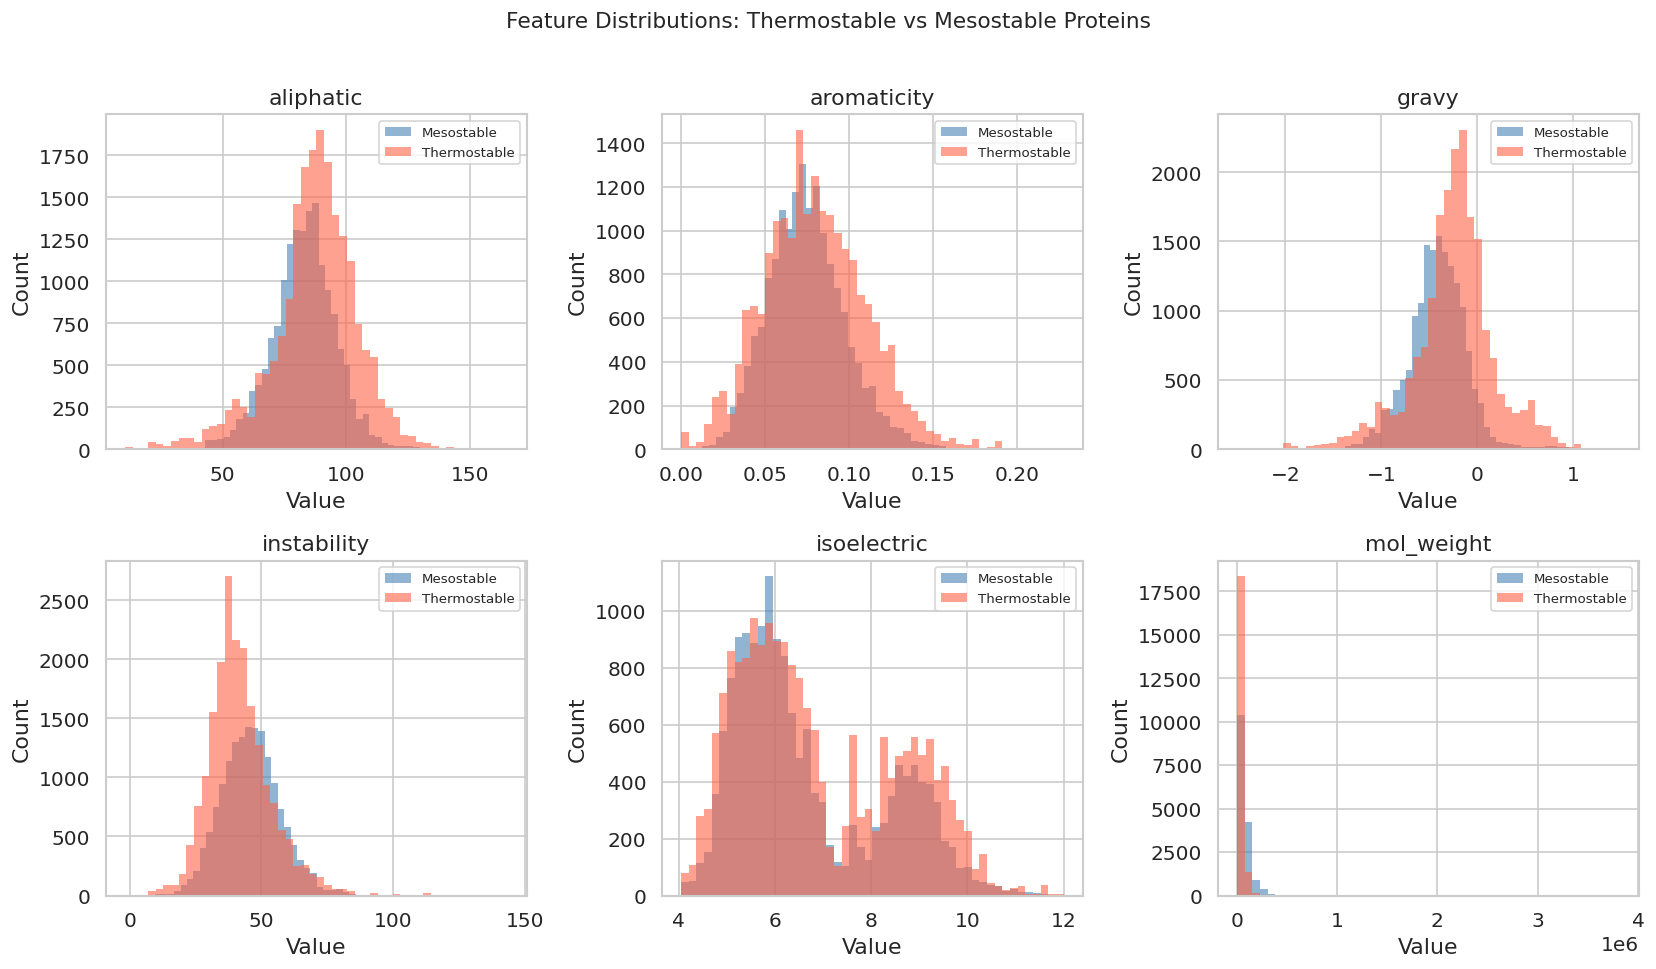

Figure saved to figures/phase2_feature_distributions.png


In [10]:
# We will plot 6 of our most biologically meaningful features
features_to_plot = ['aliphatic', 'aromaticity', 'gravy', 
                    'instability', 'isoelectric', 'mol_weight']

# Create a figure with 6 subplots arranged in 2 rows × 3 columns
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# .flatten() converts the 2D array of axes into a 1D list
# so we can loop over them easily
axes = axes.flatten()

# Define colours for each class
colors = {0: 'steelblue', 1: 'tomato'}
labels = {0: 'Mesostable', 1: 'Thermostable'}

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    # Plot distribution for each class separately
    for label_val in [0, 1]:
        # Filter rows for this class
        subset = feature_df[feature_df['label'] == label_val][feature]
        
        # Plot histogram
        ax.hist(subset, bins=50, alpha=0.6,
                color=colors[label_val],
                label=labels[label_val],
                edgecolor='none')
    
    ax.set_title(feature, fontweight='500')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Thermostable vs Mesostable Proteins',
             fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()

os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/phase2_feature_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to figures/phase2_feature_distributions.png")

### Interpretation

Look carefully at each plot — do the red (thermostable) and blue 
(mesostable) distributions differ?

- **Aliphatic index**: if the red distribution is shifted to the right 
  (higher values), this confirms that thermostable proteins have more 
  aliphatic amino acids — consistent with known biology
- **GRAVY score**: a rightward shift in red confirms thermostable 
  proteins are more hydrophobic overall
- **Instability index**: a leftward shift in red (lower values) would 
  confirm thermostable proteins are more chemically stable
- **Aromaticity**: a slight rightward shift in red confirms more 
  aromatic residues in thermostable proteins

Features where the two distributions **overlap heavily** will be weak 
predictors. Features where they are **clearly separated** will be the 
most important for our ML models. We will quantify this properly in 
Phase 3 — Exploratory Data Analysis.

## Step 9 — Save the Feature Matrix

In [11]:
SAVE_PATH = '../data/processed/03_feature_matrix.csv'

feature_df.to_csv(SAVE_PATH, index=False)

# Confirm the file was saved correctly
saved_df = pd.read_csv(SAVE_PATH)
print(f"Feature matrix saved successfully!")
print(f"  Path  : {SAVE_PATH}")
print(f"  Shape : {saved_df.shape}")
print(f"  Size  : {os.path.getsize(SAVE_PATH) / 1024 / 1024:.1f} MB")
print(f"\nPhase 2 complete! Ready for Phase 3 — Exploratory Data Analysis.")

Feature matrix saved successfully!
  Path  : ../data/processed/03_feature_matrix.csv
  Shape : (35999, 29)
  Size  : 17.5 MB

Phase 2 complete! Ready for Phase 3 — Exploratory Data Analysis.


---

## Phase 2 — Summary

| Item | Details |
|------|---------|
| Input | `data/processed/02_dataset_clean.csv` — 36,100 proteins |
| Tool | Biopython ProtParam module |
| Features computed | 26 (20 AA composition + 6 physicochemical) |
| Proteins failed | 101 (unusual characters — removed) |
| Final dataset size | 35,999 proteins |
| Output | `data/processed/03_feature_matrix.csv` — 35,999 × 29 |

## Key Concepts Learned

| Concept | Explanation |
|---------|-------------|
| Feature engineering | Converting raw biological sequences into meaningful numbers |
| Amino acid composition | Fraction of each AA in the sequence — encodes sequence bias |
| GRAVY score | Overall hydrophobicity — thermostable proteins tend to be more hydrophobic |
| Aliphatic index | Strongest single predictor of thermostability (Ikai 1980) |
| Instability index | Predicts chemical stability — important for thermal resistance |
| try/except | Graceful error handling — prevents one bad sequence from crashing everything |
| tqdm | Progress bar for long loops — essential for monitoring long computations |

## What Comes Next?

We now have a **35,999 × 26 numerical feature matrix**. Before 
training any ML models, we need to deeply understand this data — 
looking at feature distributions, correlations between features, 
and how well individual features separate the two classes.

**Phase 3 — Exploratory Data Analysis (EDA)** will do exactly this, 
producing visualisations that will inform our modelling decisions 
in Phase 4.